#Goldman Sachs All Time Stock Data

The Goldman Sachs Group, Inc. is a premier global investment banking, securities, and investment management firm headquartered in New York City, USA. Founded in 1869, the firm provides a wide range of financial services to corporations, financial institutions, governments, and individuals worldwide.

Goldman Sachs operates across key business segments including:

*Investment Banking

*Global Markets

*Asset & Wealth Management

The firm plays a vital role in global financial markets through activities such as mergers and acquisitions advisory, securities underwriting, asset management, and trading across equities, fixed income, currencies, and commodities.

Goldman Sachs is publicly listed on the New York Stock Exchange (NYSE) under the ticker symbol GS, with stock prices denominated in US Dollars (USD). With a market capitalization in the hundreds of billions of USD (subject to market conditions), it remains one of the most influential financial institutions globally.

# Goldman Sachs (GS) Stock Analysis & Forecasting

**Contents**
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Visualization
4. Stock Price Trend Analysis
5. Volatility & Risk Analysis
6. Time-Series Forecasting (ARIMA)

Upload `goldmansachs.csv` to this Colab session (left sidebar -> Files -> Upload) before running the cells below, or mount Google Drive and point `DATA_PATH` to the file.


## 1. Setup & Data Loading

In [1]:
# Install/import required libraries (Colab already has most of these)
!pip install statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


In [2]:
# Load the data

df = pd.read_csv('/content/goldmansachs.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)

df.head()


,open,high,low,close,adj_close,volume
date,,,,,,
1999-05-04,48.696575,70.3750,77.250,70.0000,76.0000,22320900
1999-05-05,47.831593,69.1250,69.875,66.2500,69.8750,7565700
1999-05-06,47.009914,67.9375,69.375,67.0625,68.0000,2905700
1999-05-07,51.291405,74.1250,74.875,66.7500,67.9375,4862300
1999-05-10,48.912811,70.6875,73.500,70.2500,73.3750,2589400


## 2. Exploratory Data Analysis (EDA)

Basic checks: shape, data types, missing values, summary statistics, and duplicate rows.


In [3]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (6709, 6)

Data types:
 open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object

Missing values:
 open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64

Duplicate rows: 0


In [4]:
df.describe()


,open,high,low,close,adj_close,volume
count,6709.000000,6709.000000,6709.000000,6709.000000,6709.000000,6.709000e+03
mean,172.861555,203.419039,205.752305,200.988455,203.349598,4.846683e+06
std,141.763484,138.213452,139.509239,136.775805,138.090323,5.740129e+06
min,38.619919,52.000000,54.540001,47.410000,54.000000,1.076000e+05
25%,78.411163,106.937500,108.312500,105.250000,106.900002,2.254500e+06
50%,130.749725,166.979996,168.470001,165.360001,167.000000,3.244700e+06
75%,191.497284,228.500000,230.330002,226.570007,228.509995,5.096600e+06
max,914.340027,914.340027,919.099976,905.309998,913.750000,1.145907e+08


In [5]:
# Date range covered by the dataset
print("Start date:", df.index.min())
print("End date:", df.index.max())
print("Total trading days:", len(df))


Start date: 1999-05-04 00:00:00
End date: 2026-01-02 00:00:00
Total trading days: 6709


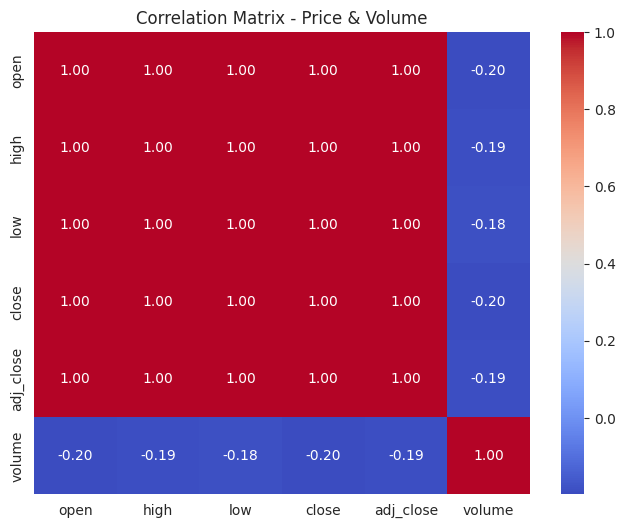

In [6]:
# Quick correlation among price/volume columns
corr = df[['open','high','low','close','adj_close','volume']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Price & Volume")
plt.show()


## 3. Data Visualization

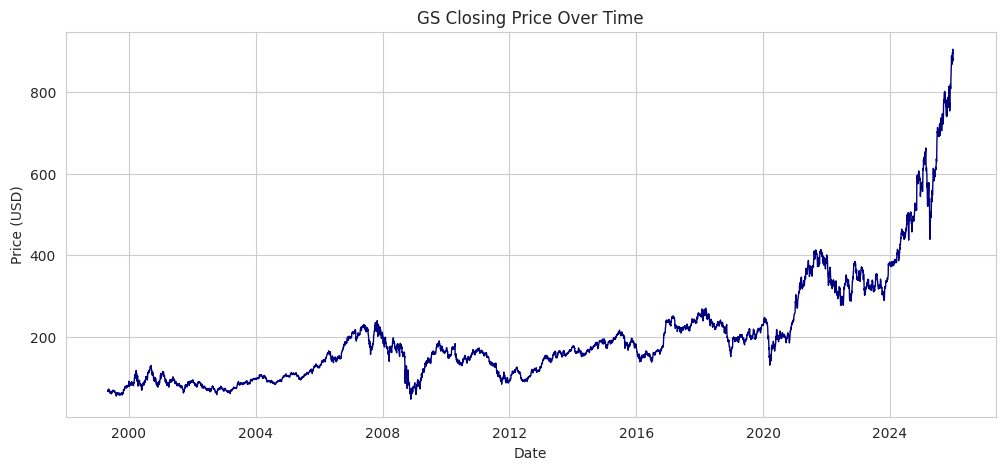

In [7]:
# Closing price over time
plt.figure()
plt.plot(df.index, df['close'], color='navy', linewidth=1)
plt.title("GS Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()


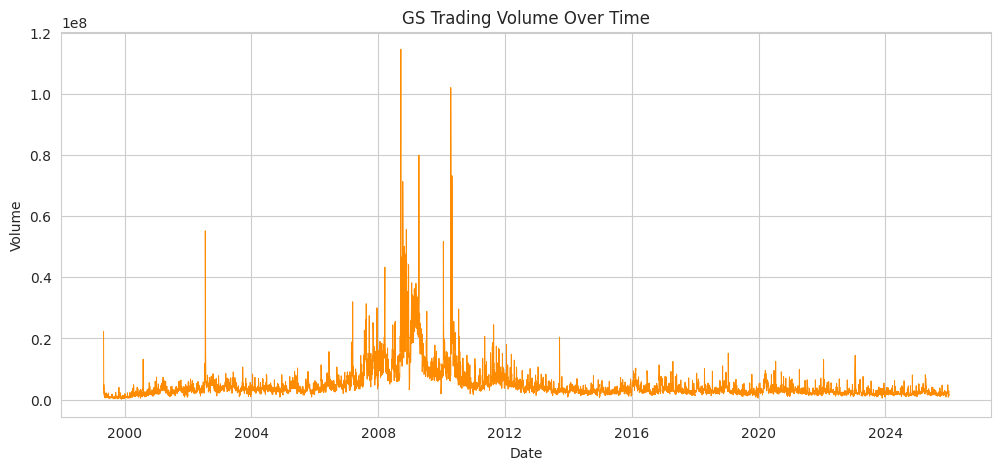

In [8]:
# Trading volume over time
plt.figure()
plt.plot(df.index, df['volume'], color='darkorange', linewidth=0.7)
plt.title("GS Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()


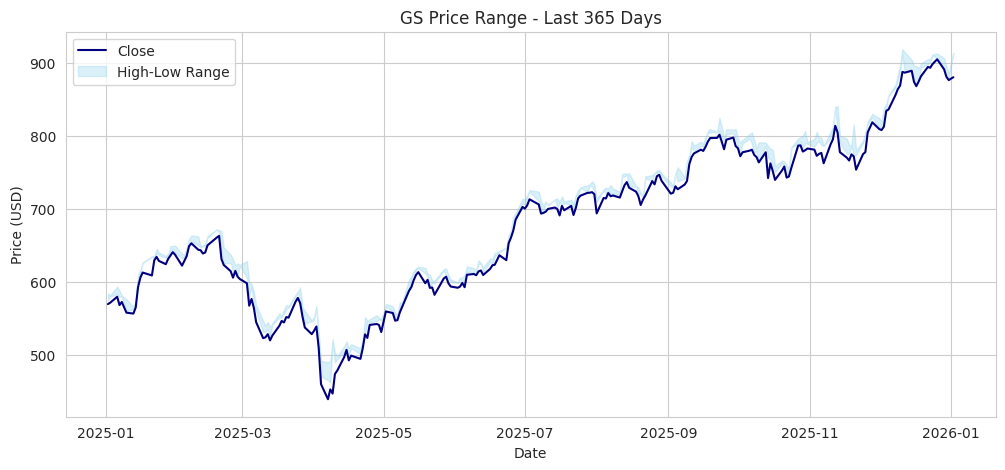

In [9]:
# Candlestick-style view for the most recent year using open/high/low/close
recent = df[df.index >= df.index.max() - pd.DateOffset(days=365)]

plt.figure()
plt.plot(recent.index, recent['close'], label='Close', color='navy')
plt.fill_between(recent.index, recent['low'], recent['high'], color='skyblue', alpha=0.3, label='High-Low Range')
plt.title("GS Price Range - Last 365 Days")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


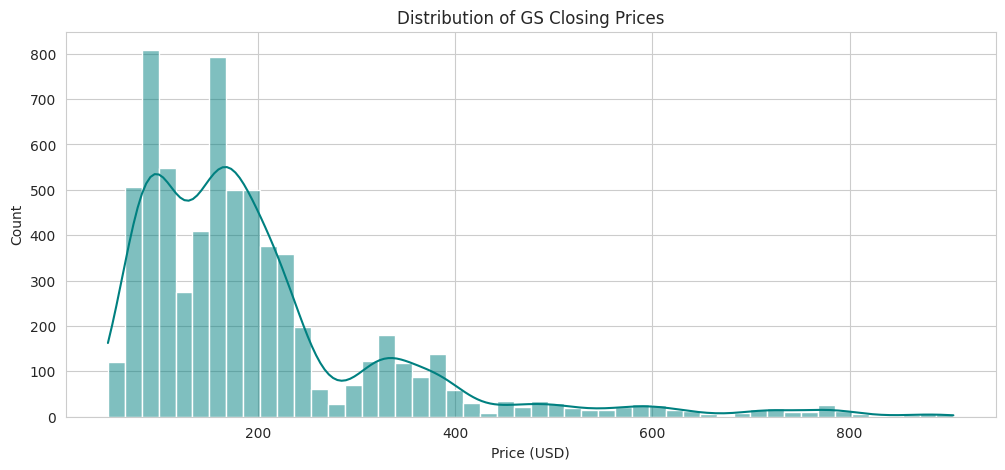

In [10]:
# Distribution of daily closing prices
plt.figure()
sns.histplot(df['close'], bins=50, kde=True, color='teal')
plt.title("Distribution of GS Closing Prices")
plt.xlabel("Price (USD)")
plt.show()


## 4. Stock Price Trend Analysis

We add short/long-term moving averages to visualize the underlying trend, and compute yearly average closing prices.


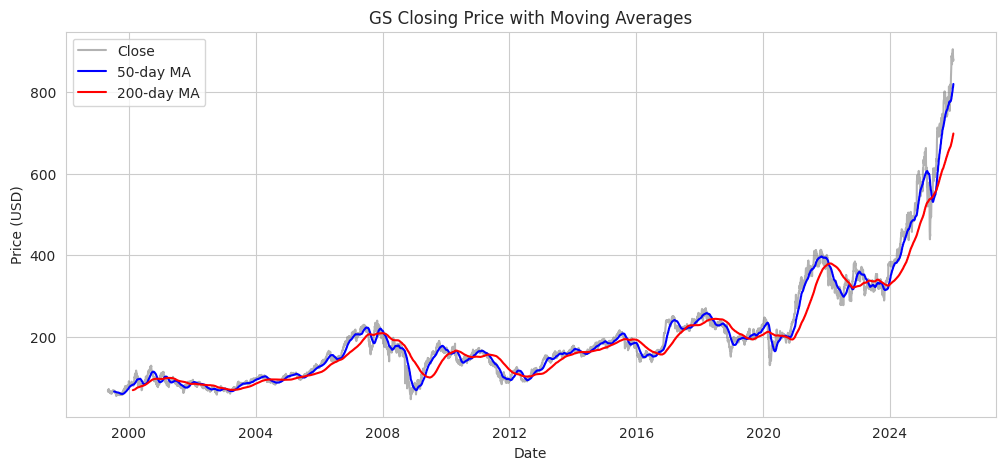

In [11]:
# Moving averages
df['MA50']  = df['close'].rolling(window=50).mean()
df['MA200'] = df['close'].rolling(window=200).mean()

plt.figure()
plt.plot(df.index, df['close'], label='Close', color='gray', alpha=0.6)
plt.plot(df.index, df['MA50'], label='50-day MA', color='blue')
plt.plot(df.index, df['MA200'], label='200-day MA', color='red')
plt.title("GS Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


In [12]:
# Golden Cross / Death Cross signal (informational)
df['signal'] = np.where(df['MA50'] > df['MA200'], 'Bullish (Golden Cross)', 'Bearish (Death Cross)')
df[['MA50','MA200','signal']].dropna().tail(10)


,MA50,MA200,signal
date,,,
2025-12-18,796.463599,682.78090,Bullish (Golden Cross)
2025-12-19,798.675599,684.36755,Bullish (Golden Cross)
2025-12-22,801.292400,686.11720,Bullish (Golden Cross)
2025-12-23,803.608800,687.97005,Bullish (Golden Cross)
2025-12-24,806.733600,689.84255,Bullish (Golden Cross)
2025-12-26,809.586600,691.72615,Bullish (Golden Cross)
2025-12-29,812.369601,693.58365,Bullish (Golden Cross)
2025-12-30,815.193000,695.35605,Bullish (Golden Cross)
2025-12-31,817.671200,697.04000,Bullish (Golden Cross)


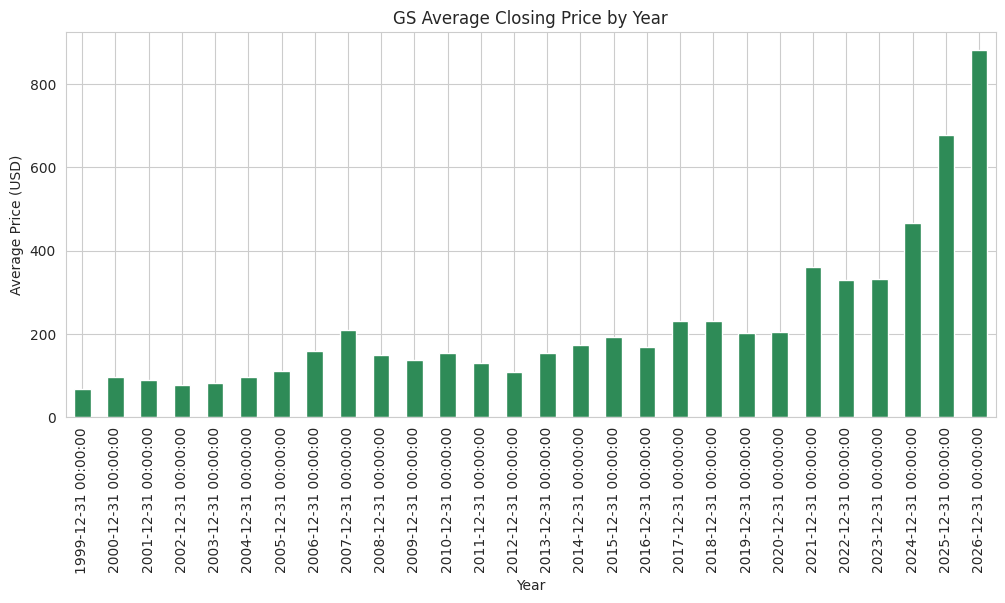

In [13]:
# Yearly average closing price trend
yearly_avg = df['close'].resample('YE').mean()

plt.figure()
yearly_avg.plot(kind='bar', color='seagreen')
plt.title("GS Average Closing Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price (USD)")
plt.show()


## 5. Volatility & Risk Analysis

We compute daily returns, rolling volatility (annualized), Value-at-Risk (VaR), and the Sharpe ratio as basic risk metrics.


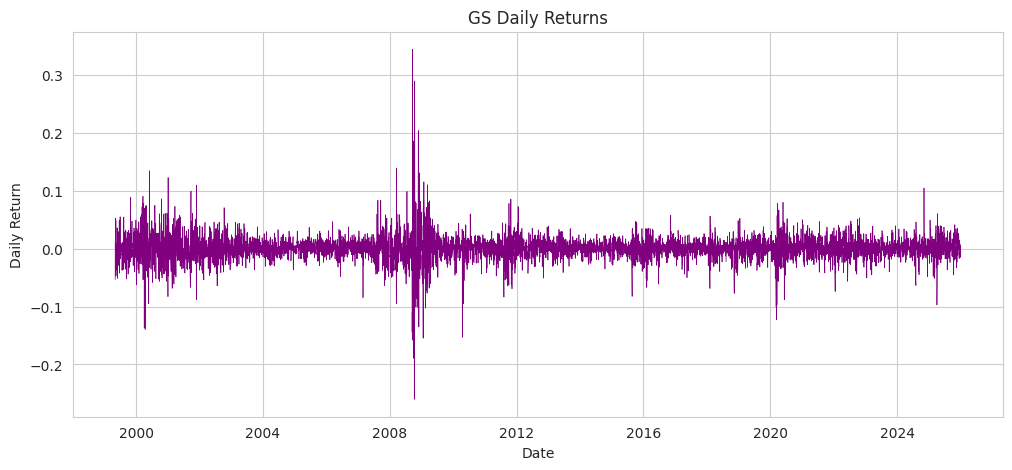

In [14]:
# Daily returns
df['daily_return'] = df['close'].pct_change()

plt.figure()
plt.plot(df.index, df['daily_return'], color='purple', linewidth=0.5)
plt.title("GS Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()


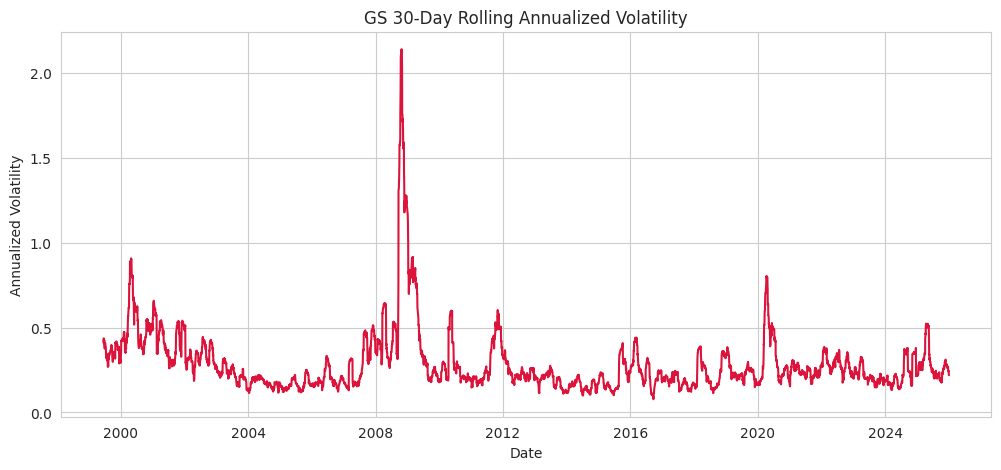

In [15]:
# Rolling volatility (annualized, 30-day window)
df['rolling_volatility'] = df['daily_return'].rolling(window=30).std() * np.sqrt(252)

plt.figure()
plt.plot(df.index, df['rolling_volatility'], color='crimson')
plt.title("GS 30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.show()


In [16]:
# Historical Value-at-Risk (VaR) at 95% confidence, using historical simulation
returns = df['daily_return'].dropna()
var_95 = np.percentile(returns, 5)
print(f"Historical 1-day VaR (95% confidence): {var_95:.4%}")
print("Interpretation: on 95% of days, losses are not expected to exceed this percentage.")


Historical 1-day VaR (95% confidence): -2.9724%
Interpretation: on 95% of days, losses are not expected to exceed this percentage.


In [17]:
# Annualized return, volatility and Sharpe ratio (risk-free rate assumed 0 for simplicity)
annual_return = returns.mean() * 252
annual_volatility = returns.std() * np.sqrt(252)
sharpe_ratio = annual_return / annual_volatility

print(f"Annualized Return:     {annual_return:.2%}")
print(f"Annualized Volatility: {annual_volatility:.2%}")
print(f"Sharpe Ratio:          {sharpe_ratio:.2f}")


Annualized Return:     15.39%
Annualized Volatility: 34.37%
Sharpe Ratio:          0.45


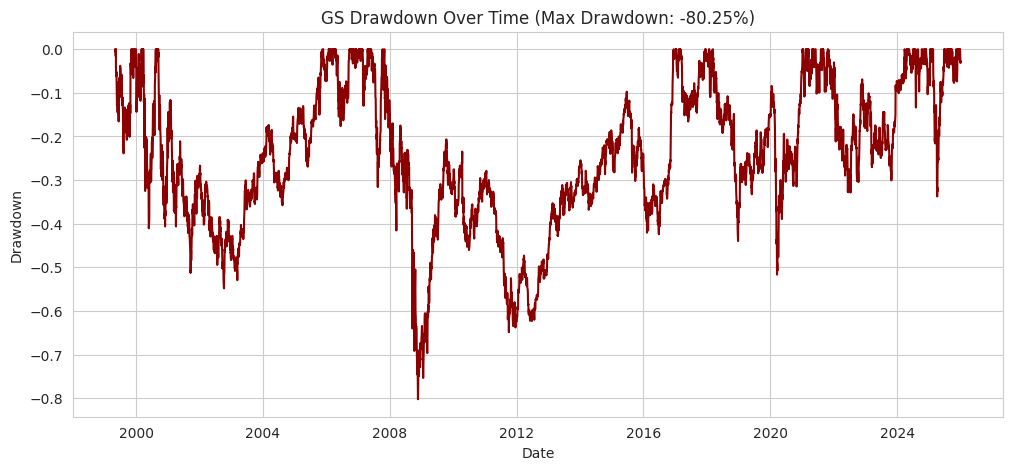

In [18]:
# Maximum drawdown
cumulative = (1 + returns).cumprod()
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min()

plt.figure()
plt.plot(drawdown.index, drawdown, color='darkred')
plt.title(f"GS Drawdown Over Time (Max Drawdown: {max_drawdown:.2%})")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()


## 6. Time-Series Forecasting (ARIMA)

A simple ARIMA model is fit on the closing price to forecast future values. We split the data into train/test sets to validate accuracy before forecasting forward.


In [19]:
# Use the last 5 years of data to keep the model fast and relevant, then split train/test
ts = df['close'].asfreq('B').ffill()  # business-day frequency, forward-fill any gaps
ts = ts[ts.index >= ts.index.max() - pd.DateOffset(years=5)]

train_size = int(len(ts) * 0.9)
train, test = ts.iloc[:train_size], ts.iloc[train_size:]

print("Train size:", len(train), " Test size:", len(test))


Train size: 1174  Test size: 131


In [20]:
# Fit a simple ARIMA(5,1,0) model - order can be tuned further using ACF/PACF plots
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 1174
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -3895.628
Date:                Wed, 05 Aug 2026   AIC                           7803.257
Time:                        06:10:47   BIC                           7833.661
Sample:                    01-04-2021   HQIC                          7814.723
                         - 07-03-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1939      0.021      9.447      0.000       0.154       0.234
ar.L2         -0.0276      0.023     -1.222      0.222      -0.072       0.017
ar.L3         -0.0018      0.024     -0.076      0.9

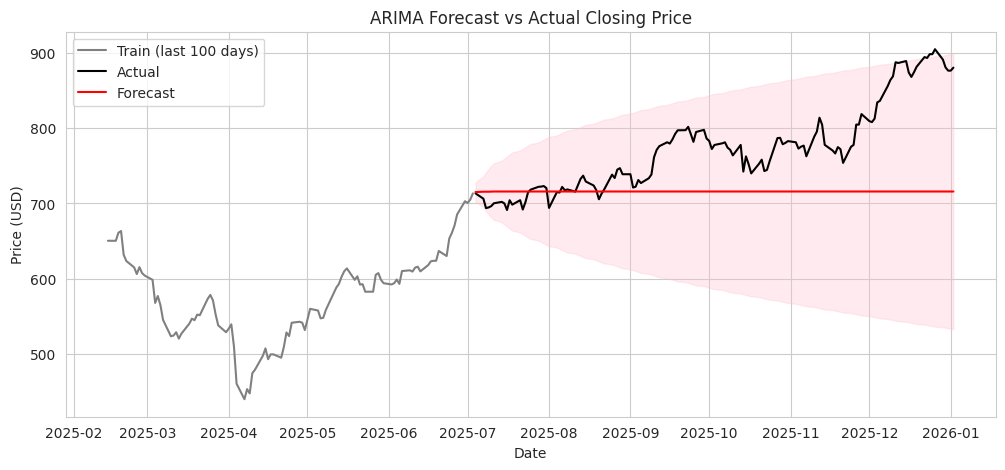

In [21]:
# Forecast over the test period and compare to actuals
forecast_result = model_fit.get_forecast(steps=len(test))
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

plt.figure()
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)', color='gray')
plt.plot(test.index, test.values, label='Actual', color='black')
plt.plot(test.index, forecast_mean, label='Forecast', color='red')
plt.fill_between(test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title("ARIMA Forecast vs Actual Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


In [22]:
# Evaluate forecast accuracy
mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
mape = np.mean(np.abs((test.values - forecast_mean.values) / test.values)) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


MAE:  61.46
RMSE: 81.31
MAPE: 7.51%


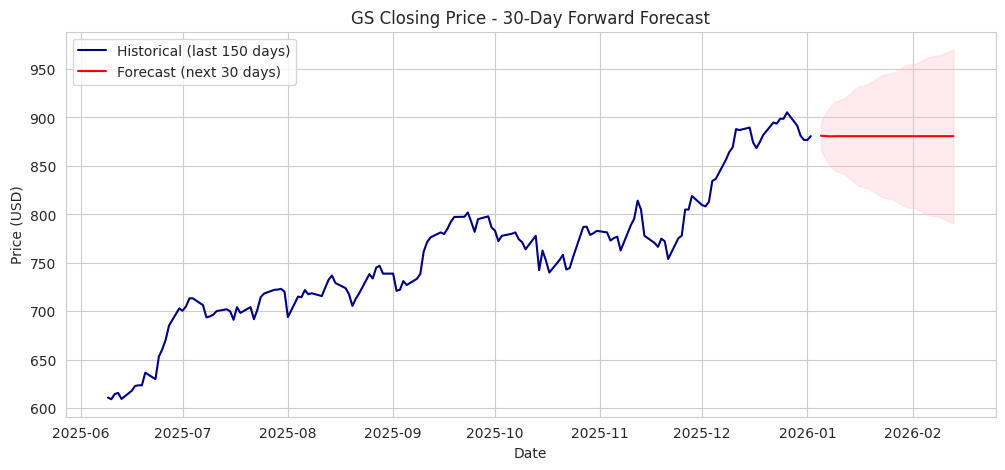

,predicted_mean
2026-01-05,881.097112
2026-01-06,880.934585
2026-01-07,880.636265
2026-01-08,880.569435
2026-01-09,880.671919
2026-01-12,880.706602
2026-01-13,880.711972
2026-01-14,880.700981
2026-01-15,880.696075
2026-01-16,880.697792


In [23]:
# Forecast the next 30 business days into the future using the full 5-year series
final_model = ARIMA(ts, order=(5,1,0))
final_fit = final_model.fit()

future_steps = 30
future_forecast = final_fit.get_forecast(steps=future_steps)
future_mean = future_forecast.predicted_mean
future_conf = future_forecast.conf_int()

plt.figure()
plt.plot(ts.index[-150:], ts.iloc[-150:].values, label='Historical (last 150 days)', color='navy')
plt.plot(future_mean.index, future_mean, label='Forecast (next 30 days)', color='red')
plt.fill_between(future_mean.index, future_conf.iloc[:,0], future_conf.iloc[:,1], color='pink', alpha=0.3)
plt.title("GS Closing Price - 30-Day Forward Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

future_mean.head(10)


## Notes & Next Steps

- The ARIMA order `(5,1,0)` is a reasonable starting point; use `plot_acf`/`plot_pacf` on the differenced series, or `auto_arima` (from `pmdarima`), to tune it further.
- For potentially stronger results, consider `Facebook Prophet` or an `LSTM` model, especially if you want to incorporate volume or macroeconomic features.
- Stock price forecasts are inherently uncertain — this notebook is for educational/analytical purposes, not investment advice.
